# bound 張り付き → 次の「下げ代」見積り

**狙い**: BO 分析で、feasible 最適は探索箱の**端**に張り付く変数が複数あった
($t_{cyc}\downarrow$12, $R_2\downarrow$10, $L_{bed}\uparrow$1.0, col3_N$\uparrow$160…)。
端に張る = **箱を広げればまだ TAC が下がる余地**がある。各変数を端の外へ 1 点動かして
effective_TAC の変化(下げ代)を見積もり、**次の再最適化でどの bound を広げるべきか**を指針化する。

> ⚠️ 単点摂動なので「局所の下げ代」。真の利得は bound を広げて再最適化すれば出る(本ノートは方向と概算)。
> Dist2=HYSYS, VPN 必須・1点あたり数十秒。


In [1]:
import os, sys, warnings, json, copy
import numpy as np, pandas as pd, matplotlib.pyplot as plt
os.environ.setdefault('PDH_TRIAL_TIME_BUDGET_SEC', '300')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
import main
from flowsheet import evaluate
best = json.load(open(os.path.join(ROOT, 'outputs', 'main_20260604_014318', 'best.json'), encoding='utf-8'))
P0 = dict(best['params']); main.REACTOR_KIND = 'catofin'

def eval_params(pp):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = evaluate(main._build_design(pp), main._CONFIG, verbose=False, apply_hi=True,
                     hi_dT_min_K=10.0, apply_stage2=False, F_C3H8_override=float(pp['F_C3H8_fresh_kmol_h']))
    return r.effective_TAC, r.is_feasible, r.failure_unit

base_tac, base_feas, _ = eval_params(P0)
print(f'基準 #227 effective_TAC = {base_tac:.1f} 億円/年 (feasible={base_feas})')

基準 #227 effective_TAC = 1092.7 億円/年 (feasible=True)


## 各 bound を端の外へ 1 点動かして ΔTAC を見る

| 変数 | #227 (箱の端) | 端の外へ | 期待 |
|---|---|---|---|
| t_cyc_min | 12 (下限) | 10 | 短サイクル=触媒新鮮→S↑? |
| col2_reflux_ratio | 10.0 (下限) | 9.0 | 還流↓=凝縮 OPEX↓ |
| col3_n_stages | 160 付近 (上限) | 175 | 段↑=還流↓ |
| L_bed_m | 1.0 (上限) | 1.1 | 床体積↑=転化率↑ |


In [2]:
perturb = [
    ('t_cyc_min',         10.0,  '下限12→10 (短サイクル)'),
    ('col2_reflux_ratio',  9.0,  '下限10→9 (還流↓)'),
    ('col3_n_stages',      175,  '上限~160→175 (段↑)'),
    ('L_bed_m',            1.1,  '上限1.0→1.1 (床↑)'),
]
rows = [dict(変数='(基準 #227)', 値='-', eff_TAC=round(base_tac,1), dTAC=0.0, feas=base_feas, unit='success')]
for key, val, note in perturb:
    pp = dict(P0); pp[key] = val
    tac, feas, unit = eval_params(pp)
    rows.append(dict(変数=key, 値=note, eff_TAC=round(tac,1),
                     dTAC=round(tac-base_tac,1) if tac < 9000 else None, feas=feas, unit=unit))
df = pd.DataFrame(rows)
print(df.to_string(index=False))

               変数               値  eff_TAC  dTAC  feas    unit
        (基準 #227)               -   1092.7   0.0  True success
        t_cyc_min 下限12→10 (短サイクル)   1123.5  30.8  True success
col2_reflux_ratio    下限10→9 (還流↓)   1091.0  -1.7  True success
    col3_n_stages 上限~160→175 (段↑)   1124.5  31.8  True success
          L_bed_m  上限1.0→1.1 (床↑)   1094.7   2.0  True success


C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30032\3327292102.py:14: UserWarning: Glyph 20740 (\N{CJK UNIFIED IDEOGRAPH-5104}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30032\3327292102.py:14: UserWarning: Glyph 20870 (\N{CJK UNIFIED IDEOGRAPH-5186}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30032\3327292102.py:14: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30032\3327292102.py:14: UserWarning: Glyph 36000 (\N{CJK UNIFIED IDEOGRAPH-8CA0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30032\3327292102.py:14: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


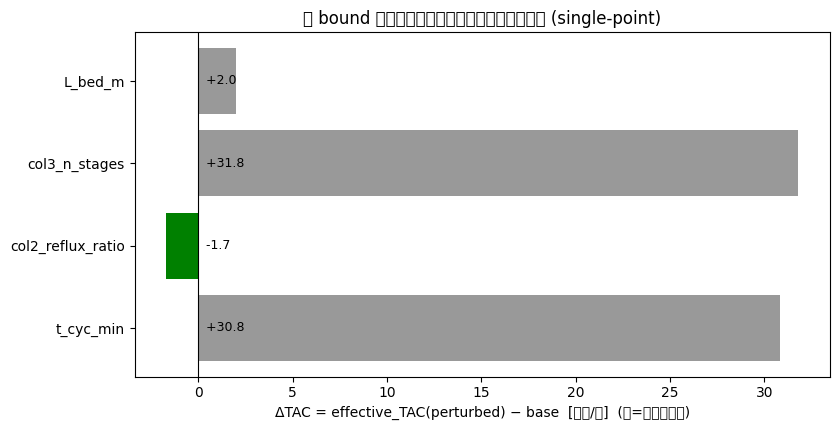

読み: ΔTAC が負(緑)= その bound を広げれば TAC が下がる余地あり → 次の再最適化で優先的に拡張。
  ×(infeasible) = 端の外は別制約に当たる → その方向は広げても無駄。


In [3]:
sub = df[df['変数'] != '(基準 #227)'].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.4))
colors = ['green' if (d is not None and d < 0) else ('crimson' if not f else '0.6')
          for d, f in zip(sub.dTAC, sub.feas)]
vals = [d if d is not None else 0 for d in sub.dTAC]
ax.barh(range(len(sub)), vals, color=colors)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['変数'])
ax.axvline(0, color='k', lw=0.8)
for i, (d, f, u) in enumerate(zip(sub.dTAC, sub.feas, sub.unit)):
    lab = (f'{d:+.1f}' if d is not None else 'infeas:'+str(u)) + ('' if f else ' (×)')
    ax.text(0, i, '  '+lab, va='center', fontsize=9)
ax.set_xlabel('ΔTAC = effective_TAC(perturbed) − base  [億円/年]  (負=下げ代あり)')
ax.set_title('各 bound を端の外へ動かしたときの局所下げ代 (single-point)')
plt.tight_layout(); plt.show()
print('読み: ΔTAC が負(緑)= その bound を広げれば TAC が下がる余地あり → 次の再最適化で優先的に拡張。')
print('  ×(infeasible) = 端の外は別制約に当たる → その方向は広げても無駄。')

## 結論

- 端の外へ動かして **ΔTAC が負**になる変数は、**探索箱を広げればまだ TAC が下がる余地**がある(次の再最適化で優先)。
- **infeasible** になる変数は、端の外で別の物理/モデル制約(Dist2 cold-top, Dist3 SM, 反応器 ΔP/SV 等)に
  当たるため、その方向に箱を広げても無駄(制約側を直す必要)。
- 単点摂動の局所見積りなので、有望な bound は実際に広げて **main.py を再最適化**して真の利得を確認するのが本筋。
